In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pnd

import matplotlib as mpl

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch
import seaborn as sbn



# inflate SEED mappings

Using external resources to be additioned to MetNetX.

In [2]:
%%bash

# extend MetaNetX SEED-to-others mappings with additional resources
wget -O seed_mappings/SEED2VMH_translation.csv https://www.vmh.life/files/reconstructions/Recon/SEED2VMH_translation.csv
wget -O seed_mappings/SEED2VMH_translation_edited.csv https://github.com/jotech/gapseq/raw/refs/heads/master/dat/SEED2VMH_translation_edited.csv

--2025-09-17 11:32:52--  https://www.vmh.life/files/reconstructions/Recon/SEED2VMH_translation.csv
Resolving www.vmh.life (www.vmh.life)... 145.239.0.239
Connecting to www.vmh.life (www.vmh.life)|145.239.0.239|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35196 (34K) [text/csv]
Saving to: ‘seed_mappings/SEED2VMH_translation.csv’

     0K .......... .......... .......... ....                 100% 2.52M=0.01s

utime(seed_mappings/SEED2VMH_translation.csv): Operation not permitted
2025-09-17 11:32:52 (2.52 MB/s) - ‘seed_mappings/SEED2VMH_translation.csv’ saved [35196/35196]

--2025-09-17 11:32:52--  https://github.com/jotech/gapseq/raw/refs/heads/master/dat/SEED2VMH_translation_edited.csv
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jotech/gapseq/refs/heads/master/dat/SEED2VMH_translation_edited

In [3]:
SEED2VMH_translation = pnd.read_csv('seed_mappings/SEED2VMH_translation.csv', header=None, names=['seed','bigg'])
SEED2VMH_translation

,seed,bigg
0,EX_cpd00001(e),EX_h2o(e)
1,EX_cpd00007(e),EX_o2(e)
2,EX_cpd00009(e),EX_pi(e)
3,EX_cpd00011(e),EX_co2(e)
4,EX_cpd00012(e),EX_ppi(e)
...,...,...
1921,rxn12851,GLYTYRabc
1922,rxn13477,IPFPHS
1923,rxn13782,pbiosynthesis
1924,rxn13783,dreplication


In [4]:
SEED2VMH_translation_edited = pnd.read_csv('seed_mappings/SEED2VMH_translation_edited.csv', header=None, names=['seed','bigg'])
SEED2VMH_translation_edited

,seed,bigg
0,EX_cpd11416(e),EX_Biomass(e)
1,EX_cpd11606(e),EX_mqn7(e)
2,EX_cpd00001(e),EX_h2o(e)
3,EX_cpd00007(e),EX_o2(e)
4,EX_cpd00009(e),EX_pi(e)
...,...,...
2115,rxn13782,pbiosynthesis
2116,rxn13783,dreplication
2117,rxn13784,rtranscription
2118,bio1,biomass


In [5]:
# load mappings provided by metanetx
with open('seed_mappings/seed_to_others_extended_R.pickle', 'rb') as f:
    seed_to_others_extended_R = pickle.load(f)

In [6]:
# inflate mapping with additional annotations

for df in [SEED2VMH_translation, SEED2VMH_translation_edited]:
    for index, row in df.iterrows(): 
        seed, bigg = row['seed'], row['bigg']
        if seed.startswith('EX_') and seed.endswith('(e)'): 
            seed = seed[:-3] + '_e'  # match convention
            bigg = bigg[:-3] + '_e'  # match convention
        if seed not in seed_to_others_extended_R.keys():
            seed_to_others_extended_R[seed] = {
                'kegg.reaction': set(),
                'biocyc': set(),
                'seed.reaction': {seed},
                'bigg.reaction': {bigg},
                'rhea': set(),
                'sabiork.reaction': set(),
                'ec-code': set(),
                'metanetx.reaction': set(),
                'reactome': set(),
                'brenda.biochemistry': set(),
                'brenda': set(),
            }
        else:
            seed_to_others_extended_R[seed]['bigg.reaction'].add(bigg)  


# save to disk
with open('seed_mappings/seed_to_others_extended_R_inflated.pickle', 'wb') as f:
    pickle.dump(seed_to_others_extended_R, f)

# define main functions

In [7]:
def get_contents_df(files):
    
    
    results_df = [] 
    for file in files:
    
        strain_id = Path(file).stem
        strain_id = strain_id.replace('_model', '')
        if '-draft' in strain_id: 
            continue    # Skip gapseq draft models

        if file.endswith('.xml'): 
            model = cobra.io.read_sbml_model(file)
        if file.endswith('.json'): 
            model = cobra.io.load_json_model(file)


        # genes
        gids = set([g.id for g in model.genes])
        G = len(gids)
        
        # reactions (no exchanges)
        rids = set([r.id for r in model.reactions if not (len(r.metabolites)==1 and list(r.metabolites)[0].id.rsplit('_', 1)[-1] in ['e', 'e0'])])
        R = len(rids)
        
        # metabolites (without compartment)
        umids = set([m.id.rsplit('_',1)[0] for m in model.metabolites])
        uM = len(umids)
        
        # exchange reactions
        exr_ids = set([r.id for r in model.reactions if (len(r.metabolites)==1 and list(r.metabolites)[0].id.rsplit('_', 1)[-1] in ['e', 'e0'])])
        exr = len(exr_ids)
        
        # "metabolic" reactions (no exr / sink / demand / diffusions):
        metR_ids = set()
        
        # "metabolic" reactions without GPR 
        orpR_ids = set()
        for r in model.reactions: 
            if len(r.metabolites) != 1:  # exclude exr/demand/sinks
                if 'diffusion' not in r.name.lower():  # exclude diffusions
                    metR_ids.add(r.id)
                    if r.gene_reaction_rule == '':
                        orpR_ids.add(r.id)
                        
            
        results_df.append({'strain': strain_id, 'metric': 'G', 'value': gids})
        results_df.append({'strain': strain_id, 'metric': 'R', 'value': rids})
        results_df.append({'strain': strain_id, 'metric': 'uM', 'value': umids})
        results_df.append({'strain': strain_id, 'metric': 'exr', 'value': exr_ids})
        results_df.append({'strain': strain_id, 'metric': 'metR', 'value': metR_ids})
        results_df.append({'strain': strain_id, 'metric': 'orpR', 'value': orpR_ids})
            
        print('▯', end='')  # loading bar

    results_df = pnd.DataFrame.from_records(results_df)
    return results_df

# main run

In [8]:
%%capture --no-stdout


for dataset in ['01_klebsiella', '02_ralstonia', '03_pseudomonas']:
    
    df_list = []
    for tool in ['reference', 'gempipe', 'gempipe_rf', 'carveme', 'gapseq', 'bactabolize']:
        
        if tool=='reference' and dataset=='01_klebsiella': 
            globber = '01_klebsiella/reference/iYL1228_edited.xml'
        if tool=='reference' and dataset=='02_ralstonia': 
            globber = '02_ralstonia/reference/iRP1476_edited.xml'
        if tool=='reference' and dataset=='03_pseudomonas': 
            globber = '03_pseudomonas/reference/iJN1463_edited.xml'
            
        if tool == 'gempipe': 
            globber = f'{dataset}/tools_runs/gempipe/output/strain_models_gf/*.json'
        if tool == 'gempipe_rf': 
            globber = f'{dataset}/tools_runs/gempipe_rf/output/strain_models_gf/*.json'
        if tool == 'carveme': 
            globber = f'{dataset}/tools_runs/carveme/output/*.xml'
        if tool == 'gapseq': 
            globber = f'{dataset}/tools_runs/gapseq/output/*/*.xml'
        if tool == 'bactabolize': 
            #globber = f'{dataset}/tools_runs/bactabolize/gapfilled/*.json'
            globber = f'{dataset}/tools_runs/bactabolize_3070/gapfilled/*.json'
        
        
        print(dataset, tool, end=': ') 
        res = parallelizer(globber, get_contents_df, nthreads=37)
        print()
        
        res['tool'] = tool
        res['dataset'] = dataset
        df_list.append(res)
        
    df_dataset = pnd.concat(df_list)
    df_dataset.to_csv(f'{dataset}/tables/contents.csv')
    

01_klebsiella reference: ▯
01_klebsiella gempipe: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
01_klebsiella gempipe_rf: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
01_klebsiella carveme: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
01_klebsiella gapseq: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
01_klebsiella bactabolize: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
02_ralstonia reference: ▯
02_ralstonia gempipe: ▯▯▯▯▯▯▯▯▯▯▯
02_ralstonia gempipe_rf: ▯▯▯▯▯▯▯▯▯▯▯
02_ralstonia carveme: ▯▯▯▯▯▯▯▯▯▯▯
02_ralstonia gapseq: ▯▯▯▯▯▯▯▯▯▯▯
02_ralstonia bactabolize: ▯▯▯▯▯▯▯▯▯▯▯
03_pseudomonas reference: ▯
03_pseudomonas gempipe: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
03_pseudomonas gempipe_rf: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
03_pseudomonas carveme: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
03_pseudomonas gapseq: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
03_pseudomonas bactabolize: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯


# compute set lengths

In [2]:
contents_01 = pnd.read_csv(f'01_klebsiella/tables/contents.csv', index_col=0)
contents_02 = pnd.read_csv(f'02_ralstonia/tables/contents.csv', index_col=0)
contents_03 = pnd.read_csv(f'03_pseudomonas/tables/contents.csv', index_col=0)
contents_all = pnd.concat([contents_01, contents_02, contents_03])
contents_all = contents_all.reset_index(drop=True)


# 'value' col is str after reading; convert back to set:
for index, row in contents_all.iterrows(): 
    contents_all.loc[index, 'value'] = eval(contents_all.loc[index, 'value'])


# compute set lengths
contents_all['value_len'] = None
for index, row in contents_all.iterrows(): 
    value_len = len(contents_all.loc[index, 'value'])
    contents_all.loc[index, 'value_len'] = value_len
    
contents_all

,strain,metric,value,tool,dataset,value_len
0,iYL1228_edited,G,"{KPN_02584, KPN_01912, KPN_04175, KPN_02194, K...",reference,01_klebsiella,1229
1,iYL1228_edited,R,"{PYRtex, ADCYRS, LPLIPAL1G160pp, FADRx2, DTMPt...",reference,01_klebsiella,1973
2,iYL1228_edited,uM,"{b2coa, hkntd, pydx5p, ichor, ppbng, unagamu, ...",reference,01_klebsiella,1055
3,iYL1228_edited,exr,"{EX_dimp_e, EX_g1p_e, EX_dcyt_e, EX_aso3_e, EX...",reference,01_klebsiella,289
4,iYL1228_edited,metR,"{ADCYRS, LPLIPAL1G160pp, FADRx2, GLUt4pp, GUI2...",reference,01_klebsiella,1669
...,...,...,...,...,...,...
2533,DTR133,R,"{AGMDA, NDP8, CBMKr, ADCYRS, LPLIPAL1G160pp, P...",bactabolize,03_pseudomonas,2403
2534,DTR133,uM,"{pydx5p, b2coa, ad, 1pqq, ppbng, cro4, 2ommbl,...",bactabolize,03_pseudomonas,1432
2535,DTR133,exr,"{EX_fer_e, EX_aso3_e, EX_gua_e, EX_ttdcea_e, E...",bactabolize,03_pseudomonas,348
2536,DTR133,metR,"{AGMDA, NDP8, CBMKr, ADCYRS, LPLIPAL1G160pp, K...",bactabolize,03_pseudomonas,2050


# gapseq conversion with metanetx

In [3]:
# The aim is to convert SEED ids into BiGG ids, in order to make gapseq comparable with the other tools.

with open('seed_mappings/seed_to_others_extended_M.pickle', 'rb') as file:
    seed_mappings_M = pickle.load(file)
with open('seed_mappings/seed_to_others_extended_R_inflated.pickle', 'rb') as file:
    seed_mappings_R = pickle.load(file)

    
for index, row in contents_all.iterrows(): 
    
    if row['tool']=='gapseq':
        if row['metric']=='G': 
            continue  # there is no translation for gene IDs
            
        ids = contents_all.loc[index, 'value']
        tranlated_ids = set()
        for i in ids:
            
            if row['metric'] in ['R', 'metR', 'orpR']: 
                currid = i.rsplit('_', 1)[0]
                if currid in seed_mappings_R.keys():
                    curr_trans = seed_mappings_R[currid]['bigg.reaction']
                    curr_trans = [k for k in curr_trans if k.startswith('R_') == False]
            
            elif row['metric'] == 'uM': 
                currid = i
                if currid in seed_mappings_M.keys():
                    curr_trans = seed_mappings_M[currid]['bigg.metabolite']
            
            elif row['metric'] == 'exr': 
                currid = i.rsplit('_', 1)[0][3:]
                if currid in seed_mappings_M.keys():
                    curr_trans = seed_mappings_M[currid]['bigg.metabolite']
                    curr_trans = [f'EX_{k}_e' for k in curr_trans]
            
            for k in curr_trans: 
                tranlated_ids.add(k)
            
        contents_all.at[index, 'value'] = tranlated_ids
        

# reference intersection

In [4]:
contents_all['value_inter'] = None
contents_all['value_len_inter'] = 0

for index, row in contents_all.iterrows(): 
    if row['metric'] != 'G':  # genes are treated separately
         
        
        ref_metric_needed = row['metric']
        if row['metric'] == 'orpR': ref_metric_needed = 'R'
        
        reference = contents_all[
            (contents_all['tool']=='reference') & \
            (contents_all['dataset']==row['dataset']) & \
            (contents_all['metric']==ref_metric_needed) \
        ]['value'].iloc[0]
        intersection = reference.intersection(contents_all.loc[index, 'value'])

        contents_all.at[index, 'value_inter'] = intersection
        contents_all.at[index, 'value_len_inter'] = len(intersection)
        
        

## G intersection

In [5]:
dataset_to_dict = {
    '01_klebsiella': pickle.load(open('01_klebsiella/tools_runs/gempipe/working/brh/iYL1228_edited.xml.refgid_to_clusters.pickle', 'rb')),
    '02_ralstonia': pickle.load(open('02_ralstonia/tools_runs/gempipe/working/brh/iRP1476_edited.xml.refgid_to_clusters.pickle', 'rb')),
    '03_pseudomonas': pickle.load(open('03_pseudomonas/tools_runs/gempipe/working/brh/iJN1463_edited.xml.refgid_to_clusters.pickle', 'rb')),
}
dataset_to_pam = {
    '01_klebsiella': pnd.read_csv('01_klebsiella/tools_runs/gempipe/output/pam.csv', index_col=0),
    '02_ralstonia': pnd.read_csv('02_ralstonia/tools_runs/gempipe/output/pam.csv', index_col=0),
    '03_pseudomonas': pnd.read_csv('03_pseudomonas/tools_runs/gempipe/output/pam.csv', index_col=0),
}



In [6]:
def ref_gid_is_present(equivalent_clusters, pam_column, gids_modeled_by_tool):
    # example call: 
    # is_present(dataset_to_dict['01_klebsiella']['KPN_04097'],  dataset_to_pam['01_klebsiella']['Kp_SB612'], gids_modeled_by_tool)
    # dataset_to_dict['01_klebsiella']['KPN_04097']: gives a set of clusters corresponding to this reference gene
    # dataset_to_pam['01_klebsiella']['Kp_SB612']: gives strain-specific genes for each cluster
    # gids_modeled_by_tool: gives strain-specific genes modeled by the tool.
    
    
    found = False
    for cluster in equivalent_clusters: 
        if type(pam_column[cluster]) != float:
            for cds in pam_column[cluster].split(';'):
                
                if cds in gids_modeled_by_tool:
                    found = True
                    
    return found

In [7]:

for index, row in contents_all.iterrows(): 
    if row['metric'] == 'G': 
        
        reference_gids = contents_all[
            (contents_all['tool']=='reference') & \
            (contents_all['dataset']==row['dataset']) & \
            (contents_all['metric']==row['metric']) \
        ]['value'].iloc[0]  
        
        if row['tool'] == 'reference': 
            contents_all.at[index, 'value_len_inter'] = len(reference_gids)
            continue  
        
        cnt = 0
        for ref_gid in reference_gids:
            if ref_gid in dataset_to_dict[row['dataset']].keys():
                if ref_gid_is_present(
                    equivalent_clusters = dataset_to_dict[row['dataset']][ref_gid], 
                    pam_column = dataset_to_pam[row['dataset']][row['strain']],
                    gids_modeled_by_tool = row['value']
                ):
                    cnt += 1
            
        contents_all.at[index, 'value_len_inter'] = cnt
        

# plot intersection G/R/uM/exr

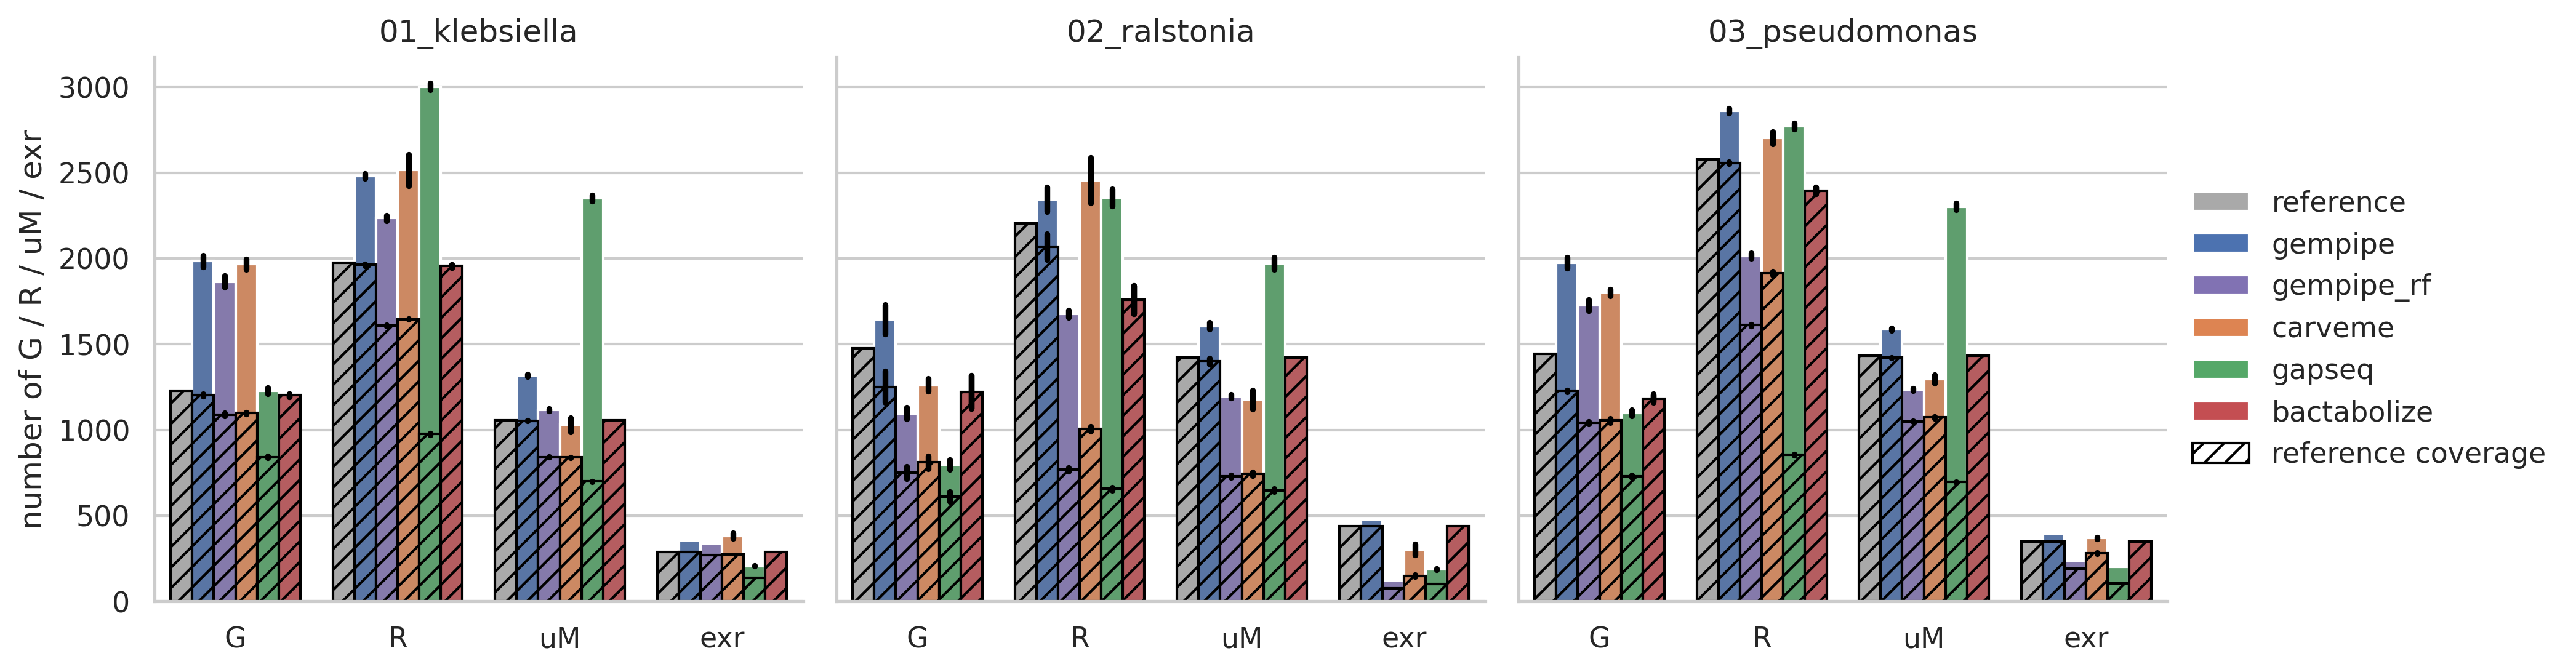

In [25]:
df = contents_all[contents_all['metric'].isin(['G','R','uM','exr'])]


sbn.set_theme(style="whitegrid")

palette1 = {
    'reference': 'darkgrey', 
    'gempipe': 'C0', 
    'gempipe_rf': 'C4', 
    'carveme': 'C1', 
    'gapseq': 'C2', 
    'bactabolize': 'C3', 
    #'bactabolize_3070': 'C6',
}
g = sbn.FacetGrid(df, col="dataset", height=4)
g = g.map_dataframe(sbn.barplot, x='metric', y='value_len', hue='tool', palette=palette1, edgecolor='white', errorbar='sd', err_kws={'color': 'black'})
g = g.map_dataframe(sbn.barplot, x='metric', y='value_len_inter', hue='tool', palette=palette1, edgecolor='black', errorbar='sd', err_kws={'color': 'black'})


for dataset in g.axes:
    for ax in dataset:
        for bars in ax.containers[int(len(ax.containers)/2):]:
            for bar in bars:
                bar.set_hatch('///')

g.set_axis_labels('', 'number of G / R / uM / exr')


# custom legend: 
plt.legend()
patches = [Patch(facecolor=value, edgecolor='white', label=key) for key, value in palette1.items()]
hatched_patch = Patch(facecolor='none', edgecolor='black', hatch='///', label='reference coverage')
patches = patches + [hatched_patch]
legend = plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 0.5))
legend.set_frame_on(False)


axes = g.axes.flatten()
axes[0].set_title("01_klebsiella")
axes[1].set_title("02_ralstonia")
axes[2].set_title("03_pseudomonas")

g.fig.set_dpi(300)

g.savefig("figures/Figure 2A.png", dpi=300, bbox_inches="tight")
g

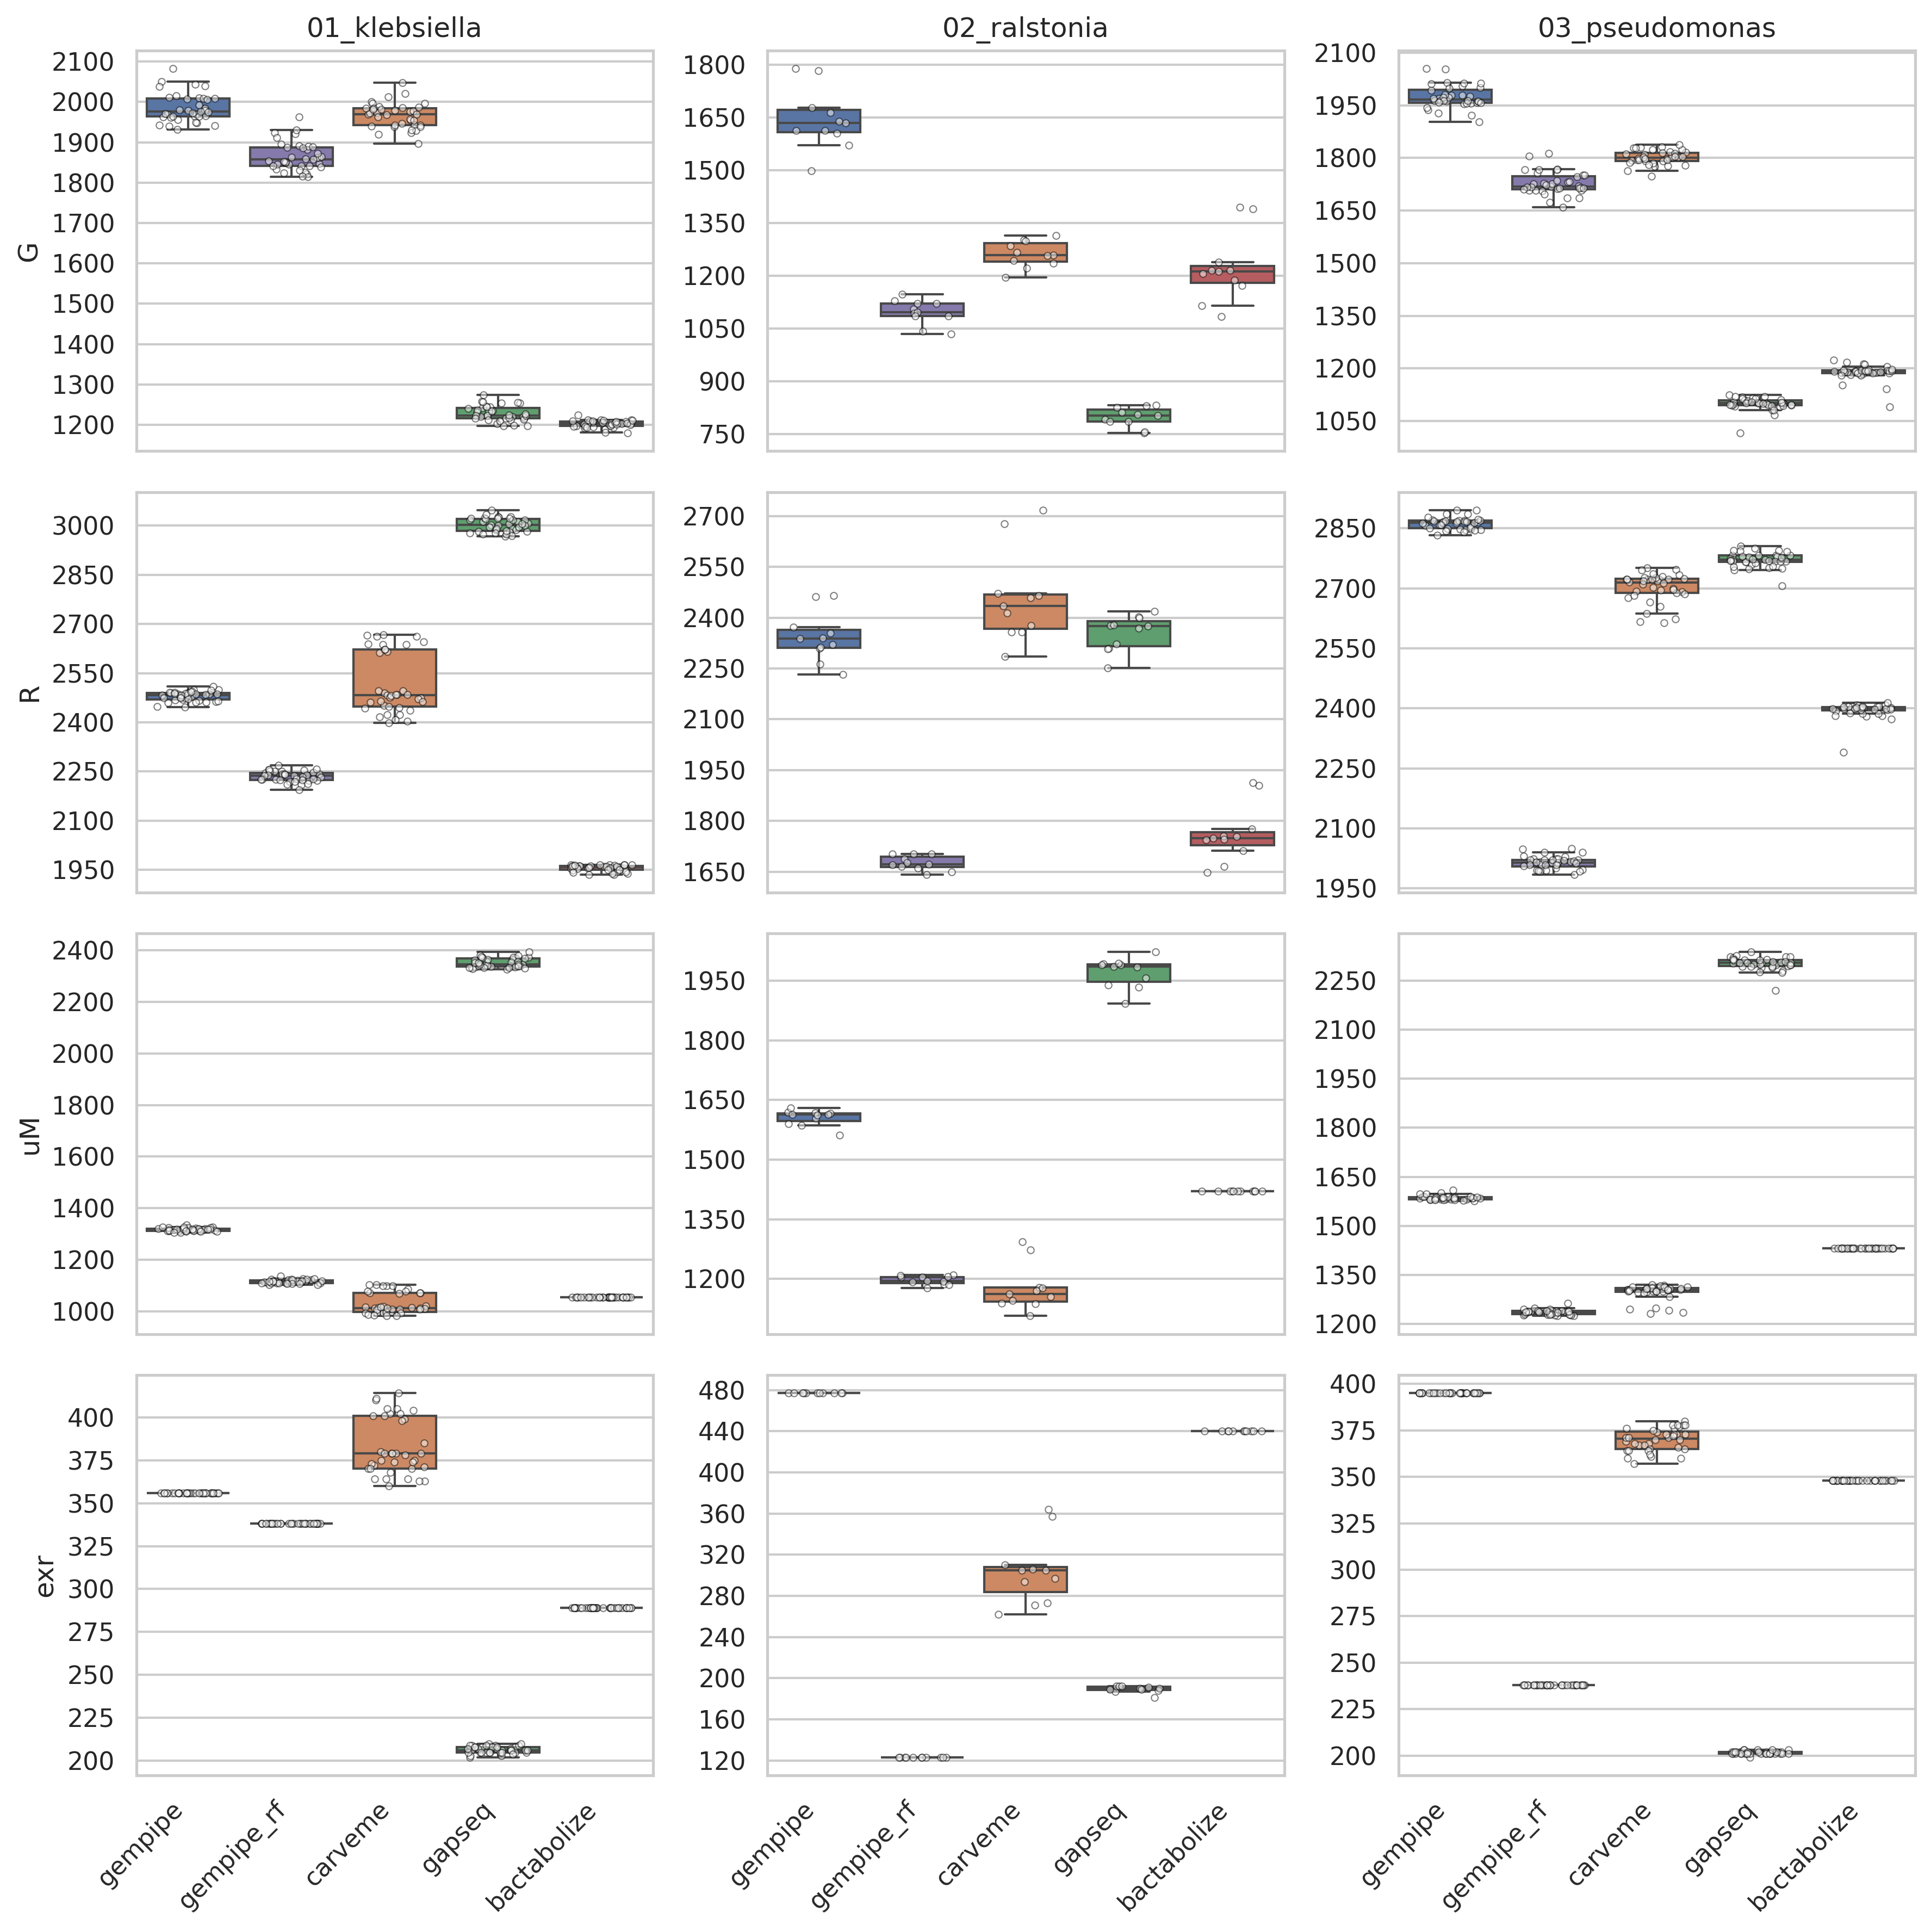

In [12]:



def boxplot_contents(df):    
    
    df_boxplots = df.copy()
    df_boxplots = df_boxplots[['strain', 'tool', 'metric', 'dataset', 'value_len']]
    df_boxplots = df_boxplots[df_boxplots['tool'] != 'reference']
    
    tool_colors = {
        "gempipe_pan": "C5",
        "gempipe": "C0",
        "gempipe_rf": "C4",
        "carveme": "C1",
        "gapseq": "C2",
        "bactabolize_pan": "C8",
        'bactabolize_pan_3070': 'C9',
        "bactabolize": "C3",
        #'bactabolize_3070': 'C6',
    }

    # create subplots according to the datasets
    datasets = sorted(df_boxplots['dataset'].unique())
    metrics = ['G', 'R', 'uM', 'exr']
    fig, axes = plt.subplots(len(metrics), len(datasets), figsize=(4 * len(datasets), 3 * len(metrics)), dpi=300)


    # iterate subplots / datasets
    for c, dataset in enumerate(datasets):
        df_boxplots_sub = df_boxplots[df_boxplots["dataset"] == dataset]


        # ---- PLOT ----
        tool_order = [t for t in tool_colors.keys() if t in df_boxplots_sub['tool'].unique()]
        for r, metric in enumerate(metrics):
            df_boxplots_sub_metric = df_boxplots_sub[df_boxplots_sub["metric"] == metric]
            

            # draw boxplots
            sbn.boxplot(
                data=df_boxplots_sub_metric,
                x="tool",
                y="value_len",
                hue="tool",
                #order=metrics,
                palette=tool_colors,
                dodge=False,
                ax=axes[r, c],
                fliersize=0,  # size of the outlier markers (“fliers”) in the boxplot (0 because of the swarmplot, see below)
                legend=False
            )

            
            sbn.stripplot(
                data=df_boxplots_sub_metric,
                x="tool",
                y="value_len",
                ax=axes[r, c],
                color="white",
                alpha=0.5,
                linewidth=0.5,
                edgecolor='black',
                size=3,
                jitter=0.3,  # increase spread (0.4 ≈ 40% of category width)
            )

            
            if r==0: axes[r, c].set_title(dataset, fontsize = 12)
            axes[r, c].set_xlabel('')
            if c==0: axes[r, c].set_ylabel(metric, fontsize=12)
            else:
                axes[r, c].set_ylabel('')
            if r == len(metrics)-1:
                axes[r, c].set_xticks(range(len(tool_order)))
                axes[r, c].set_xticklabels(tool_order, rotation=45, ha="right")
            else:
                axes[r, c].set_xticks(range(len(tool_order)))
                axes[r, c].set_xticklabels([])

            # ensure y-axis shows only integers
            axes[r, c].yaxis.set_major_locator(MaxNLocator(integer=True))

            #ax.spines["top"].set_visible(False)
            #ax.spines["right"].set_visible(False)



    fig.tight_layout()
    plt.show()
    
boxplot_contents(df)

# correlation matrix (R)

In [26]:

df = contents_all[contents_all['metric']=='R']
corr_matrix = []

# execute a tool1 VS tool2:
for dataset in df['dataset'].unique():
    
    df_dataset = df[df['dataset']==dataset]
    
    for tool1 in df_dataset['tool'].unique():
        for tool2 in df_dataset['tool'].unique():

            all_strains = []

            # for each strain, excluding the reference model:
            for strain in df_dataset[df_dataset['tool']!='reference']['strain'].unique():


                # define the 2 set for which to compute jaccard:
                if tool1=='reference':
                    set1 = df_dataset[df_dataset['tool']=='reference']['value'].iloc[0]
                else:
                    set1 = df_dataset[(df_dataset['tool']==tool1) & (df_dataset['strain']==strain)]['value'].iloc[0]

                if tool2=='reference':
                    set2 = df_dataset[df_dataset['tool']=='reference']['value'].iloc[0]
                else:
                    set2 = df_dataset[(df_dataset['tool']==tool2) & (df_dataset['strain']==strain)]['value'].iloc[0]


                jaccard = len(set1.intersection(set2)) / len(set1.union(set2))
                all_strains.append(jaccard)

            mean_jaccard = sum(all_strains)/len(all_strains)
            corr_matrix.append({'dataset': dataset, 'tool1': tool1, 'tool2': tool2, 'value': mean_jaccard})

            
corr_matrix = pnd.DataFrame.from_records(corr_matrix)
corr_matrix

,dataset,tool1,tool2,value
0,01_klebsiella,reference,reference,1.000000
1,01_klebsiella,reference,gempipe,0.788825
2,01_klebsiella,reference,gempipe_rf,0.619189
3,01_klebsiella,reference,carveme,0.579678
4,01_klebsiella,reference,gapseq,0.209032
...,...,...,...,...
103,03_pseudomonas,bactabolize,gempipe,0.835756
104,03_pseudomonas,bactabolize,gempipe_rf,0.542366
105,03_pseudomonas,bactabolize,carveme,0.548710
106,03_pseudomonas,bactabolize,gapseq,0.162335


# plot correlation matrix

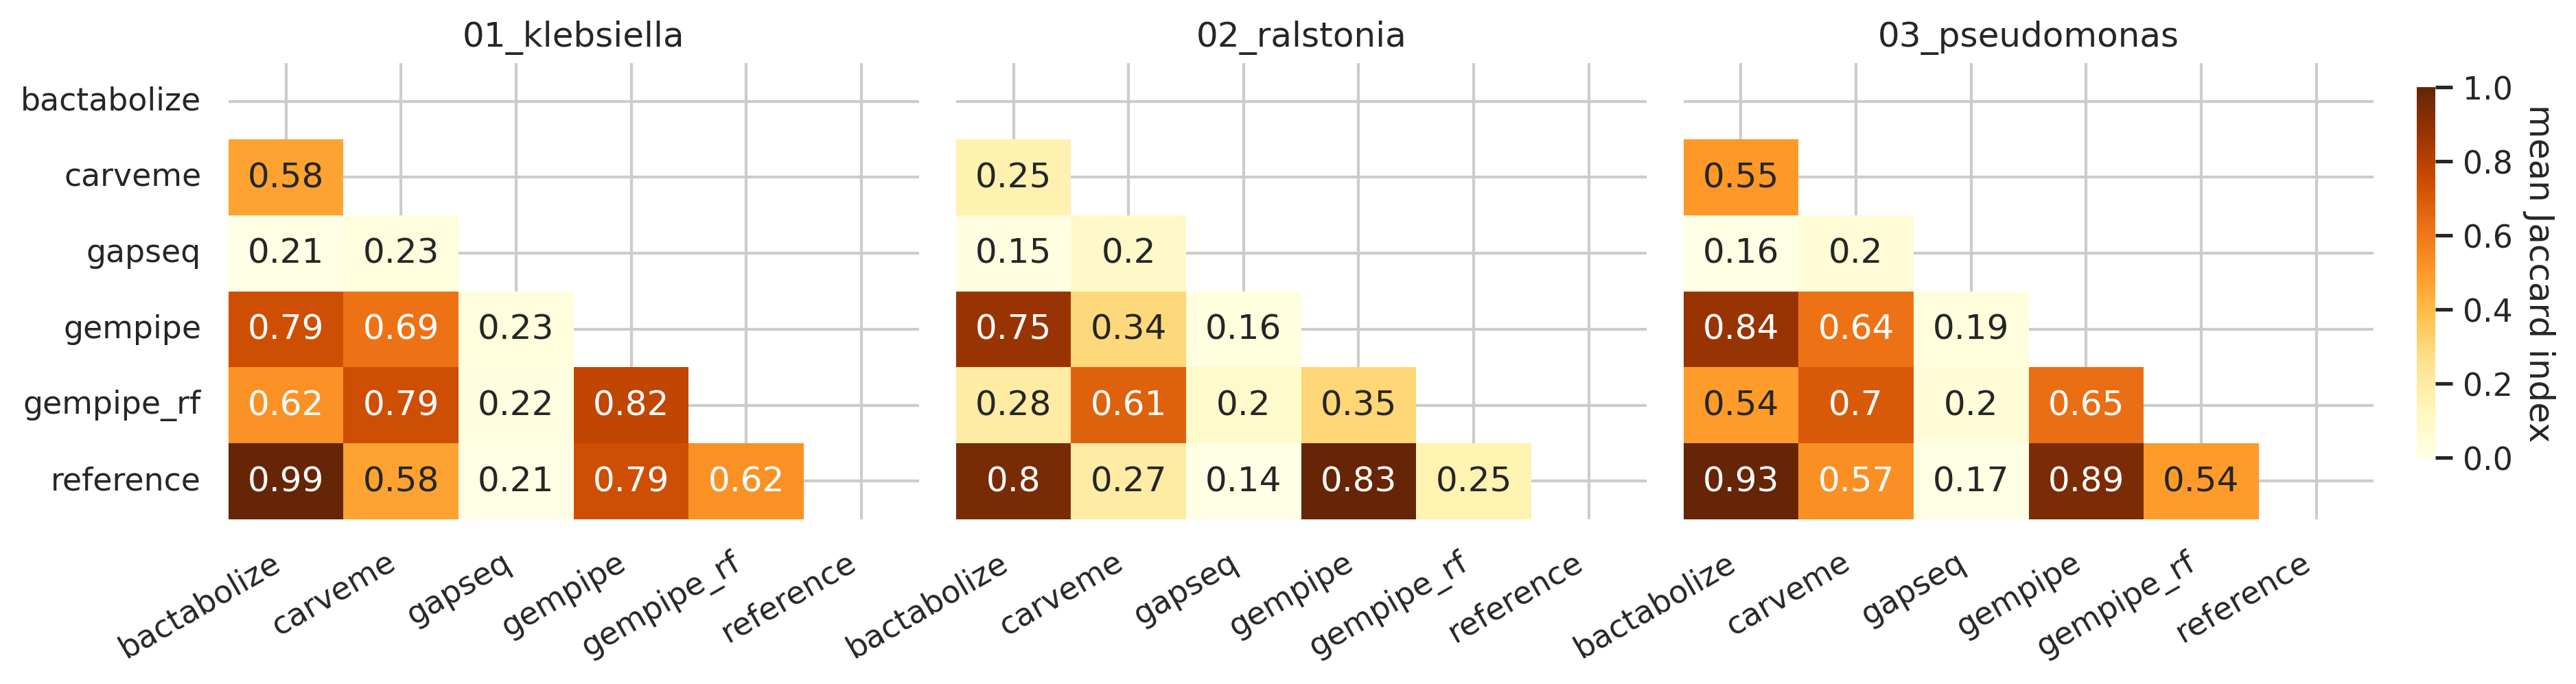

In [27]:
sbn.set_theme(style="whitegrid")
        

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    triangular  = np.triu(np.ones_like(d ))
    sbn.heatmap(d, mask=triangular,  cmap="YlOrBr", annot=True, **kwargs)
    
    
g = sbn.FacetGrid(corr_matrix, col='dataset', height=4)
g.map_dataframe(draw_heatmap, 'tool1', 'tool2', 'value', cbar=False, square=False)


axes = g.axes.flatten()
axes[0].set_title("01_klebsiella")
axes[1].set_title("02_ralstonia")
axes[2].set_title("03_pseudomonas")

g.set_axis_labels('', '')

g.set_xticklabels(rotation=30, ha='right')


# show a colormap 
ax3 = g.fig.add_axes([0.96, 0.4, 0.05, 0.5])  # [left, bottom, width, height]
ax3.set_facecolor('none')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_xticklabels([])
ax3.set_yticklabels([])
cmap = plt.get_cmap('YlOrBr')  # Colormap
norm = mpl.colors.Normalize(vmin=0, vmax=1)  
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy data array, not used but required
cbar = plt.colorbar(sm, ax=ax3, orientation='vertical')
cbar.outline.set_visible(False)
cbar.set_label('mean Jaccard index', rotation=270, labelpad=15)

g.fig.set_dpi(300)

g.savefig("figures/Figure 2B.png", dpi=300, bbox_inches="tight")
g

In [28]:
from PIL import Image, ImageDraw, ImageFont

img_a = Image.open("figures/Figure 2A.png")
img_b = Image.open("figures/Figure 2B.png")

max_width = max(img_a.width, img_b.width)
total_height = img_a.height + img_b.height

# create new blank (white) image with the right dimensions
combined = Image.new("RGB", (max_width, total_height), "white")

# paste images, centered
x_offset_a = (max_width - img_a.width) // 2
x_offset_b = (max_width - img_b.width) // 2
combined.paste(img_a, (x_offset_a, 0))
combined.paste(img_b, (x_offset_b, img_a.height))

# add labels
draw = ImageDraw.Draw(combined)
font = ImageFont.truetype(   # 60 wits well with 300dpi
    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf", 60)


# add "A" at top-left of 2a
draw.text((10, 10), "A", font=font, fill="black")
# add "B" at top-left of 2b (relative to its starting y position)
draw.text((10, img_a.height + 10), "B", font=font, fill="black")

combined.save("figures/Figure 2.png", dpi=(300, 300))

# plot orphan reactions

In [29]:
relative = True    # if True, the value is normalized to the number of metabolic reactions in the model

df = contents_all[contents_all['metric'].isin(['metR', 'orpR'])].copy()

if relative:   
    for index, row in df.iterrows(): 
        if row['metric'] == 'orpR': 

            n_metR = df[ \
                (df['strain']==row['strain']) & \
                (df['dataset']==row['dataset']) & \
                (df['tool']==row['tool']) & \
                (df['metric']=='metR') \
            ]['value_len'].iloc[0]    

            df.at[index, 'value_len'] =  df.loc[index, 'value_len'] / n_metR * 100
            df.at[index, 'value_len_inter'] =  df.loc[index, 'value_len_inter'] / n_metR * 100
        


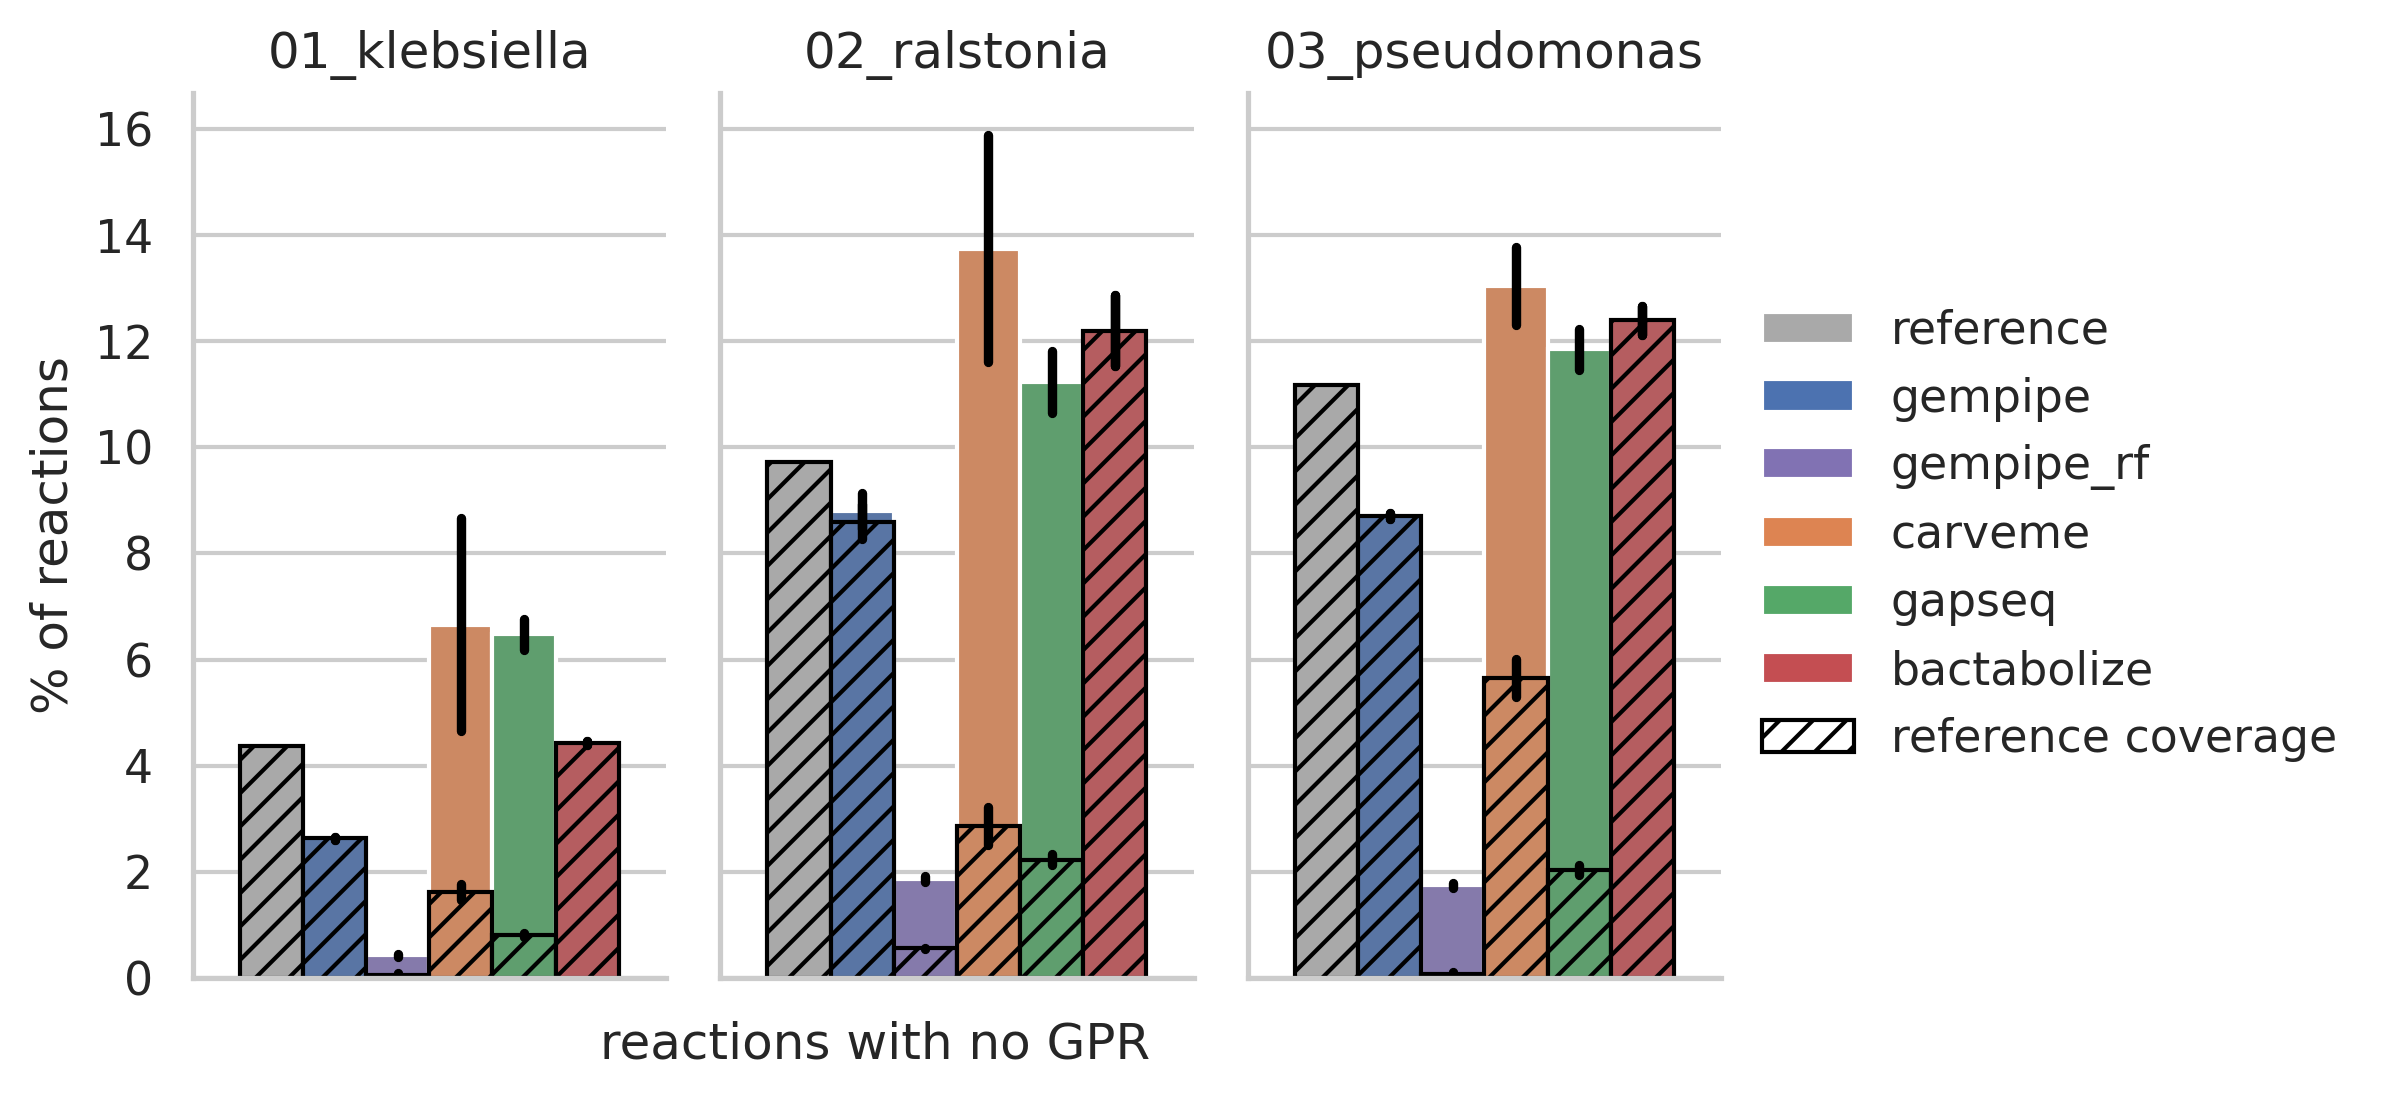

In [30]:
df = df[df['metric'].isin(['orpR'])]

sbn.set_theme(style="whitegrid")

palette1 = {'reference': 'darkgrey', 'gempipe': 'C0', 'gempipe_rf': 'C4', 'carveme': 'C1', 'gapseq': 'C2', 'bactabolize': 'C3'}
g = sbn.FacetGrid(df, col="dataset", height=4, aspect=0.5)
g = g.map_dataframe(sbn.barplot, x='metric', y='value_len', hue='tool', palette=palette1, edgecolor='white', errorbar='sd', err_kws={'color': 'black'})
g = g.map_dataframe(sbn.barplot, x='metric', y='value_len_inter', hue='tool', palette=palette1, edgecolor='black', errorbar='sd', err_kws={'color': 'black'})


for dataset in g.axes:
    for ax in dataset:
        for bars in ax.containers[int(len(ax.containers)/2):]:
            for bar in bars:
                bar.set_hatch('///')

                
if relative: g.set_axis_labels('', '% of reactions')
else : g.set_axis_labels('', 'number of reactions')


axes = g.axes.flatten()
axes[0].set_title("01_klebsiella")
axes[1].set_title("02_ralstonia")
axes[2].set_title("03_pseudomonas")


# remove x-axis labels
for ax in axes:
    ax.set_xticks([]) 
# add global x-axis label
g.fig.text(0.5, 0.1, 'reactions with no GPR', ha='center')


# custom legend: 
plt.legend()
patches = [Patch(facecolor=value, edgecolor='white', label=key) for key, value in palette1.items()]
hatched_patch = Patch(facecolor='none', edgecolor='black', hatch='///', label='reference coverage')
patches = patches + [hatched_patch]
legend = plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 0.5))
legend.set_frame_on(False)

g.fig.set_dpi(300)

g.savefig("figures/Figure 5.png", dpi=300, bbox_inches="tight")
g